# Drehzahlmessung

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import scipy as sp
import numpy as np

font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 11}

matplotlib.rc('font', **font)


## k3-Wert Berechnung

[2.16006048 2.04600409 1.95000195 2.00161241 1.93598064] 2.018731914778832


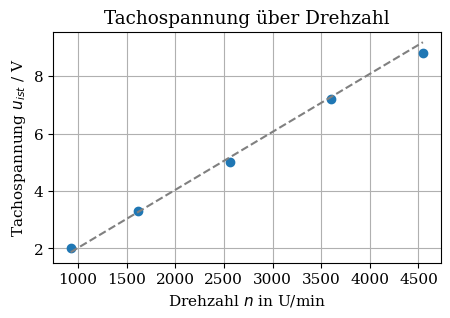

In [3]:
u_ist = np.array([2.0, 3.3, 5.0, 7.2, 8.8])
n = np.array([925.9, 1612.9, 2564.1, 3597.1, 4545.5])
k3 = u_ist / n * 1e3  # in mVmin/U
k3_mean = np.mean(k3)
print(k3, k3_mean)

n_lin = np.linspace(n[0], n[-1], 100)
u_lin = k3_mean * n_lin * 1e-3  # in V

plt.figure(figsize=(5,3))
plt.plot(n, u_ist, marker='o', linestyle='None')
plt.plot(n_lin, u_lin, linestyle='--', color='gray')
plt.xlabel('Drehzahl $n$ in U/min')
plt.ylabel('Tachospannung $u_{ist}$ / V')
plt.grid()
plt.title('Tachospannung über Drehzahl')
plt.savefig('latex/images/11_tachospannung_drehzahl.png', dpi=300, bbox_inches='tight')

## Stroboskopische Drehzahlmessung

In [4]:
f = np.array([15.43, 26.87, 41.60, 58.20, 75.00])
u_A = np.array([4.02, 8.04, 11.9, 16.1, 20.3])
n = f * 60     # in U/min
nua = n / u_A  # in U/minV
print(n)
print(nua)

[ 925.8 1612.2 2496.  3492.  4500. ]
[230.29850746 200.52238806 209.74789916 216.89440994 221.67487685]


## Numerische Lösung der TP-Zeitkonstante für Minimalen Ripple

In [15]:
def u_ripple(u_b, t_on, t_off, tau):
    e_on = t_on / tau
    e_off = t_off / tau
    numer = (np.exp(e_off)-1)*(1-np.exp(-e_on))
    denom = np.exp(e_off)-np.exp(-e_on)
    return u_b * numer / denom

t_refl = 600e-3
t_on = 10e-3
t_off = t_refl - t_on
u_ripple_set = 0.2
t = lambda x: u_ripple(5, t_on, t_off, x)-u_ripple_set

tau_init = 200e-3
tau = sp.optimize.root(t, x0=tau_init).x[0]

C = 2.2e-6

R = tau / C
print("Tiefpass Dimensionierung:")
print(f"C = {C}F,\ntau = {tau}s\n=> R = {R} Ohm")

Tiefpass Dimensionierung:
C = 2.2e-06F,
tau = 0.24398786150365154s
=> R = 110903.57341075069 Ohm
